# Digital Payments Settlement Latency & Merchant Churn Analytics
### Group 03 — Programming for Analytics · Comprehensive Group Capstone Project & Live Code Defense
> **TEMPLATE NOTEBOOK** — complete the numbered `STEP`s to build the full analysis. Every block states
> the **goal**, **hints** (the exact pandas idioms), and fine-grained **steps of at most 3 lines of code**
> each. Keep this notebook beside `payments_analytics.db`; run *Restart Kernel → Run All Cells* — it
> executes cleanly at every stage (unfinished steps hold `None` placeholders). The executed
> `..._SOLUTION.ipynb` shows one valid completion.

| # | Team Member | SAP ID | Roll Number | Email ID | % Contribution |
|---|-------------|--------|-------------|----------|----------------|
| 1 | *Member A (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 2 | *Member B (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 3 | *Member C (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 4 | *Member D (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 5 | *Member E (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 6 | *Member F (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 7 | *Member G (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |

**Architecture:** **SQL extracts** the five tables once into labelled DataFrames; **pandas does all the
work afterwards** — cleaning, integrity, EDA, aggregation, diagnostics.
**Libraries:** `numpy`, `pandas`, `matplotlib`, `seaborn` (+ built-in `sqlite3`).
**How to work:** run all cells first, then solve the blocks top-to-bottom, re-running as you go.

## 1 · Setup & Configuration *(worked example — nothing to change)*
Imports, display/plot settings, the `run_sql` extraction helper over Python's built-in `sqlite3`,
and small utilities used by later steps.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")          # keep outputs clean for evaluation
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9.5, 4.2), "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.labelsize": 10, "font.size": 9.5,
})

DB_PATH = Path("payments_analytics.db")
assert DB_PATH.exists(), "payments_analytics.db not found — keep it beside this notebook."
CONN = sqlite3.connect(DB_PATH)


def run_sql(sql: str) -> pd.DataFrame:
    """Extract data from the SQLite database into a DataFrame (extraction layer only)."""
    return pd.read_sql_query(sql, CONN)


TIER_ORDER = ["ENTERPRISE", "MID_MARKET", "SMB"]


def success_rate(status: pd.Series) -> float:
    """Success rate (%) = SUCCESS attempts / all attempts x 100."""
    return status.eq("SUCCESS").mean() * 100


def label_bars(ax, fmt="{:,.0f}"):
    """Value labels on top of vertical bars."""
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")


print("Environment ready — pandas", pd.__version__, "| seaborn", sns.__version__)

Environment ready — pandas 3.0.5 | seaborn 0.13.2


## 2 · SQL Extraction — the Five Tables into Labelled DataFrames *(worked example)*
**Goal:** pull each relational table once into a labelled DataFrame; parse dates.
**Schema:** 3 dimensions (`dim_merchants`, `df_banks`, `df_methods`) → 2 facts (`df_txns`,
`df_settlements`), 1:N from each dimension into the facts; merchant × bank × method meet in the
transaction fact (N:M).
**Steps 2.1–2.3** extract the tables, **Step 2.4** parses datetimes, **Step 2.5** reports shapes.

In [2]:
# STEP 2.1 — extract the three dimensions (one run_sql call each)
df_merchants = run_sql("SELECT merchant_id, business_name, mcc_category, onboarding_date, merchant_tier, settlement_cycle_sla, is_active, churn_date, churn_reason FROM dim_merchants")
df_banks = run_sql("SELECT bank_id, bank_name, bank_code, tier, base_network_reliability_pct FROM dim_issuing_banks")
df_methods = run_sql("SELECT payment_method_id, payment_channel, network_provider, mdr_rate_pct FROM dim_payment_methods")

# STEP 2.2 — extract the two facts (the big tables)
df_txns = run_sql("SELECT txn_id, merchant_id, bank_id, payment_method_id, txn_timestamp, amount_inr, status, error_code, latency_ms, is_routed_via_dynamic_sla FROM fact_payment_transactions")
df_settlements = run_sql("SELECT settlement_id, merchant_id, settlement_batch_date, gross_volume_inr, net_mdr_deducted_inr, net_settled_amount_inr, expected_settlement_date, actual_settlement_date, settlement_delay_days, sla_breach_flag FROM fact_merchant_settlements")

# STEP 2.3 — sanity-check the row counts you expect (8,500 merchants / 12 banks / 16 methods / 530k txns / 125k settlements)
print(len(df_merchants), len(df_banks), len(df_methods), len(df_txns), len(df_settlements))

8500 12 16 530000 125000


In [3]:
# STEP 2.4 — parse datetimes (three lines: transactions, settlements, merchants)
df_txns["txn_timestamp"] = pd.to_datetime(df_txns["txn_timestamp"], format="%Y-%m-%d %H:%M:%S")
df_settlements[["settlement_batch_date", "expected_settlement_date", "actual_settlement_date"]] = df_settlements[["settlement_batch_date", "expected_settlement_date", "actual_settlement_date"]].apply(pd.to_datetime)
df_merchants[["onboarding_date", "churn_date"]] = df_merchants[["onboarding_date", "churn_date"]].apply(pd.to_datetime)

# STEP 2.5 — report the shape of every labelled frame (one line)
print({n: d.shape for n, d in [("df_merchants", df_merchants), ("df_banks", df_banks), ("df_methods", df_methods), ("df_txns", df_txns), ("df_settlements", df_settlements)]})

{'df_merchants': (8500, 9), 'df_banks': (12, 5), 'df_methods': (16, 4), 'df_txns': (530000, 10), 'df_settlements': (125000, 10)}


## 3 · Relational Integrity Validation
**Goal (block 3):** prove PK uniqueness, zero FK orphans, the settlement ledger identity
(`net = gross − MDR`), and quantify join fan-out — before any analysis trusts the joins.
**Hints:** `df.duplicated(subset=['col']).sum()` counts duplicate keys · a left `merge(..., how='left',
indicator=True)` marks unmatched children with `_merge == 'left_only'` (never inflates rows) ·
`(series_a - series_b).abs()` for identity gaps · `groupby().agg()` with `size`/`nunique` for fan-out.

In [4]:
# STEP 3.1 — duplicate primary keys: count repeated txn_id values in df_txns (expect 0)
# hint: df_txns.duplicated(subset=['txn_id']).sum()
dup_pk = None  # TODO: compute the count of duplicated transaction PKs

# STEP 3.2 — write a reusable orphan counter for a child (key) -> parent (parent_key) pair
def orphan_count(child, key, parent, parent_key):
    # hint: child[[key]].merge(parent[[parent_key]], left_on=key, right_on=parent_key, how='left', indicator=True)
    # hint: orphans = rows where the indicator equals 'left_only'; return their count as int
    ...  # TODO: replace this ellipsis with your merge + count logic (2 lines)

# STEP 3.3 — settlement ledger identity: |net_settled - (gross - mdr)| > 0.01 count (expect 0)
# hint: build the gap series with .abs(), then wrap the > 0.01 mask in int((...).sum())
bad_ledger = None  # TODO

# STEP 3.4 — join fan-out: max & average txns/settlements per merchant
# hint: df_txns.groupby('merchant_id').agg(txns=('txn_id', 'size'), banks=('bank_id', 'nunique'))
fanout = None  # TODO

# STEP 3.5 — assert the contract (uncomment once 3.1-3.3 are solved)
# assert dup_pk == 0 and bad_ledger == 0
print("Block 3 status — dup_pk:", dup_pk, "| bad_ledger:", bad_ledger, "| orphan helper returns:", orphan_count(df_txns.iloc[0:0], "merchant_id", df_merchants, "merchant_id"))

Block 3 status — dup_pk: None | bad_ledger: None | orphan helper returns: None


## 4 · Data Quality Audit & Treatment Decisions
**Goal (block 4):** NULL audit, categorical domain conformance, temporal coverage, and a written
decisions table (Q1–Q6) justifying every treatment choice.
**Hints:** `df.isnull().sum()` per column · `~series.isin({...})` counts out-of-domain rows ·
`(a == b)` on two boolean series finds pairing mismatches · `df['date'].min() / .max()` for coverage ·
wrap your decisions in `IPython.display.Markdown` for the graded narrative.

In [5]:
# STEP 4.1 — NULL audit: which columns of df_txns and df_merchants have NULLs, and how many?
# hint: df_txns.isnull().sum() then select the columns where the count is > 0
nulls_txns = None  # TODO

# STEP 4.2 — domain check: count rows whose status is NOT in the 4-value dictionary (expect 0)
# hint: (~df_txns['status'].isin(['SUCCESS', 'FAILED', 'USER_DROPPED', 'TIMEOUT'])).sum()
bad_status = None  # TODO

# STEP 4.3 — pairing check: SUCCESS must coincide exactly with error_code == 'ERR_NONE'
# hint: (df_txns['status'].eq('SUCCESS') != df_txns['error_code'].eq('ERR_NONE')).sum()
pairing_violations = None  # TODO

# STEP 4.4 — temporal coverage: min & max of txn_timestamp, settlement dates, onboarding (one line each)
# hint: df_txns['txn_timestamp'].agg(['min', 'max'])
txn_range = None  # TODO

# STEP 4.5 — stub-month check: settlement actual-date months after 2024-12 (T+2/T+3 spillover)
# hint: df_settlements.loc[df_settlements['actual_settlement_date'] >= '2025-01-01'] — how many rows?
stub_batches = None  # TODO

print("Block 4 status — bad_status:", bad_status, "| pairing_violations:", pairing_violations, "| txn_range:", type(txn_range).__name__, "| stub_batches:", stub_batches)

Block 4 status — bad_status: None | pairing_violations: None | txn_range: NoneType | stub_batches: None


In [6]:
# STEP 4.6 — write the decisions table (graded!): build a Markdown table with 6 rows Q1..Q6
# hint: from IPython.display import Markdown, display as ipy_display; then ipy_display(Markdown(f\"\"\"...\"\"\"))
# cover: churn NULLs keep-as-is · integrity clean · 4-value status domain · 2025-01 stub month policy ·
#        latency/amount bounds respected · settlement coverage analysis within the covered population
decisions_md = None  # TODO: build and display your decisions Markdown
print("Block 4 status — decisions_md:", type(decisions_md).__name__)

Block 4 status — decisions_md: NoneType


## 5 · Analytical Preparation (pandas feature engineering)
**Goal (block 5):** calendar keys, churn flag, settlement coverage parity, and the shared
**`df_merchant_exposure`** frame (per-merchant batches / breach rate / GPV / MDR + exposure bucket)
reused by KBQ 4 and KBQ 8.
**Hints:** `dt.strftime('%Y-%m')` builds month keys, `dt.hour` the hour · `notna()` makes the churn
flag · `groupby('merchant_id').agg(...)` builds merchant-level exposure · `np.select([...], [...],
default=...)` assigns buckets: `0%` when rate == 0, `0-10%` when ≤ 0.10, `10-25%` when ≤ 0.25,
else `>25%`.

In [7]:
# STEP 5.1 — calendar keys on df_txns (worked — these are mechanical)
df_txns["month"] = df_txns["txn_timestamp"].dt.strftime("%Y-%m")
df_txns["hour"] = df_txns["txn_timestamp"].dt.hour

# STEP 5.2 — calendar keys on df_settlements (two lines, same idioms, batch + actual dates)
df_settlements["batch_month"] = df_settlements["settlement_batch_date"].dt.strftime("%Y-%m")
df_settlements["settle_month"] = df_settlements["actual_settlement_date"].dt.strftime("%Y-%m")

# STEP 5.3 — churn flag on df_merchants
# hint: df_merchants['churn_date'].notna()
df_merchants["is_churned"] = df_merchants["churn_date"].notna()

In [8]:
# STEP 5.4 — per-merchant settlement exposure: batches, breach_rate, gpv_inr, mdr_inr
# hint: df_settlements.groupby('merchant_id').agg(batches=('settlement_id', 'size'),
#        breach_rate=('sla_breach_flag', 'mean'), gpv_inr=('gross_volume_inr', 'sum'),
#        mdr_inr=('net_mdr_deducted_inr', 'sum')).reset_index()
per_merchant = None  # TODO

# STEP 5.5 — merge merchant attributes onto the exposure and add breach buckets (two steps, 3 lines max each)
df_merchant_exposure = None  # TODO: per_merchant.merge(df_merchants, on='merchant_id')
# hint: np.select([rate == 0, rate <= 0.10, rate <= 0.25], ['0%', '0-10%', '10-25%'], default='>25%')
BUCKET_ORDER = ["0%", "0-10%", "10-25%", ">25%"]

# STEP 5.6 — coverage parity: churn % for merchants with vs without settlements (unbiasedness check)
# hint: df_merchants.assign(covered=df_merchants['merchant_id'].isin(set(df_settlements['merchant_id'])))
#        then groupby('covered')['is_churned'].mean() * 100
parity = None  # TODO

print("Block 5 status — per_merchant:", type(per_merchant).__name__, "| exposure:", type(df_merchant_exposure).__name__, "| parity:", type(parity).__name__)

Block 5 status — per_merchant: NoneType | exposure: NoneType | parity: NoneType


## 6 · Descriptive Baseline — the Business at a Glance
**Goal (block 6):** one KPI band, the monthly volume/success/latency trend, and the channel mix.
**Hints:** `success_rate(df_txns['status'])` (helper is provided) · `df_txns.groupby('month').agg(...)`
with named aggregations · join `df_methods` onto `df_txns` to get `mdr_rate_pct`, filter
`status == 'SUCCESS'`, then MDR = `amount_inr * mdr_rate_pct / 100` · chart: monthly bars + success
line on a twin axis; channel GMV bars with `label_bars`.

In [9]:
# STEP 6.1 — headline KPIs as a dict: total txns, success rate %, avg latency, GMV (Rs M),
# breach rate %, realized MDR, merchant count, churn % (one expression each)
kpi = None  # TODO: e.g. kpi = {'total_txns': len(df_txns), 'success_rate_pct': success_rate(df_txns['status']), ...}

# STEP 6.2 — monthly trend frame: month, txns, sr_pct, avg_latency_ms
# hint: df_txns.groupby('month').agg(txns=('txn_id', 'size'), sr_pct=('status', success_rate),
#        avg_latency_ms=('latency_ms', 'mean')).reset_index()
monthly = None  # TODO

# STEP 6.3 — channel mix: join methods, keep SUCCESS rows, build mdr_amount_inr, group by channel
# hint (3 lines): df_txns_methods = df_txns.merge(df_methods, on='payment_method_id')
#                 df_success = df_txns_methods[df_txns_methods['status'] == 'SUCCESS'].copy()
#                 df_success['mdr_amount_inr'] = df_success['amount_inr'] * df_success['mdr_rate_pct'] / 100
channel = None  # TODO: groupby('payment_channel').agg(... gmv in Rs M ...)

print("Block 6 status — kpi:", type(kpi).__name__, "| monthly:", type(monthly).__name__, "| channel:", type(channel).__name__)

Block 6 status — kpi: NoneType | monthly: NoneType | channel: NoneType


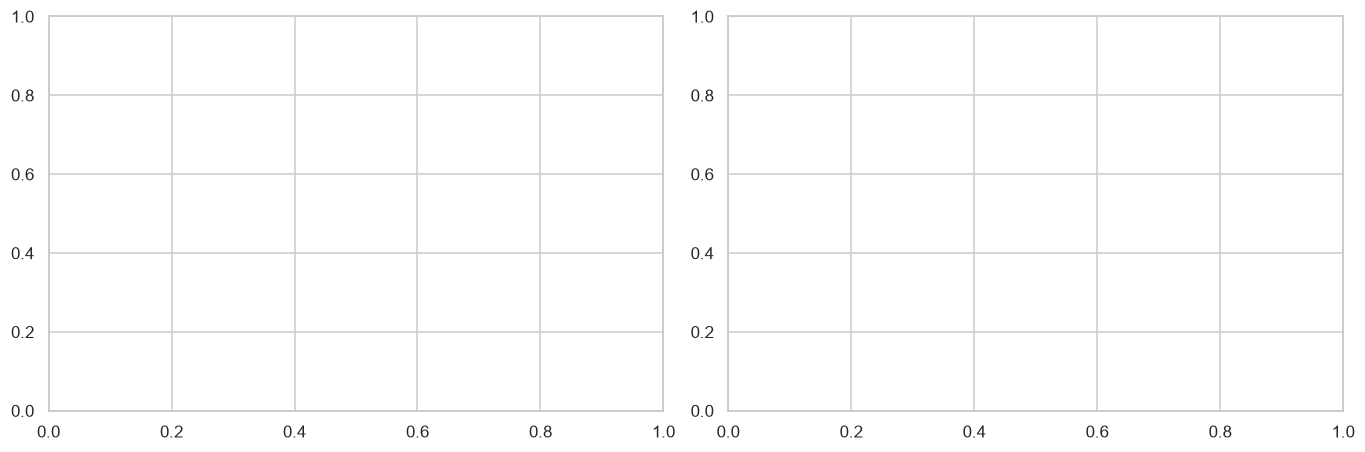

Block 6 charts: scaffold rendered (empty until you add plotting calls).


In [10]:
# STEP 6.4 — two-panel figure: (left) monthly volume bars + success-rate line on a twin axis;
# (right) channel GMV bars. The scaffold below runs — add your plotting calls, then plt.show().
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
# TODO: left panel — ax1.bar(monthly['month'], monthly['txns'] / 1e3); twin axis ax1.twinx() for sr line
# TODO: right panel — ax2.bar(channel['payment_channel'], channel['gmv_success_m']); label_bars(ax2)
plt.tight_layout(); plt.show()
print("Block 6 charts: scaffold rendered (empty until you add plotting calls).")

## 7 · Part 1 — KBQ 1: Issuing-Bank Latency & Switch-Degradation Profiling
**Goal (block 7):** per-bank volume / success / timeout / avg latency / **p95** / spike share (≥10 s);
PSU vs private rollup; hourly stress profile.
**Hints:** join banks first (`df_txns.merge(df_banks, on='bank_id')`) — boolean helper columns
(`status.eq('TIMEOUT')`, `latency_ms >= 10_000`) make `mean()` aggregations read like English ·
p95 is one call: `groupby('bank_name')['latency_ms'].quantile(0.95)` · remember `* 100` on rate columns.

In [11]:
# STEP 7.1 — join bank attributes onto transactions (worked)
df_txns_banks = df_txns.merge(df_banks, on="bank_id")

# STEP 7.2 — boolean helper columns (worked — they power the aggregations)
df_txns_banks["is_timeout"] = df_txns_banks["status"].eq("TIMEOUT")
df_txns_banks["is_spike"] = df_txns_banks["latency_ms"] >= 10_000

# STEP 7.3 — bank profile: groupby(['bank_name', 'tier']).agg(txns, sr_pct, timeout_pct, avg_latency_ms, spike_pct)
# hint: mean() on the boolean columns gives fractions — multiply the rate columns by 100 afterwards
bank_profile = None  # TODO

# STEP 7.4 — p95 latency per bank
# hint: df_txns_banks.groupby('bank_name')['latency_ms'].quantile(0.95) -> rename + merge onto bank_profile
bank_p95 = None  # TODO

# STEP 7.5 — PSU vs private: same aggregations grouped by 'tier' only
tier_cmp = None  # TODO

# STEP 7.6 — hourly profile: txns, sr_pct, avg latency, spike count per hour of day
hourly = None  # TODO

print("Block 7 status — bank_profile:", type(bank_profile).__name__, "| tier_cmp:", type(tier_cmp).__name__, "| hourly:", type(hourly).__name__)

Block 7 status — bank_profile: NoneType | tier_cmp: NoneType | hourly: NoneType


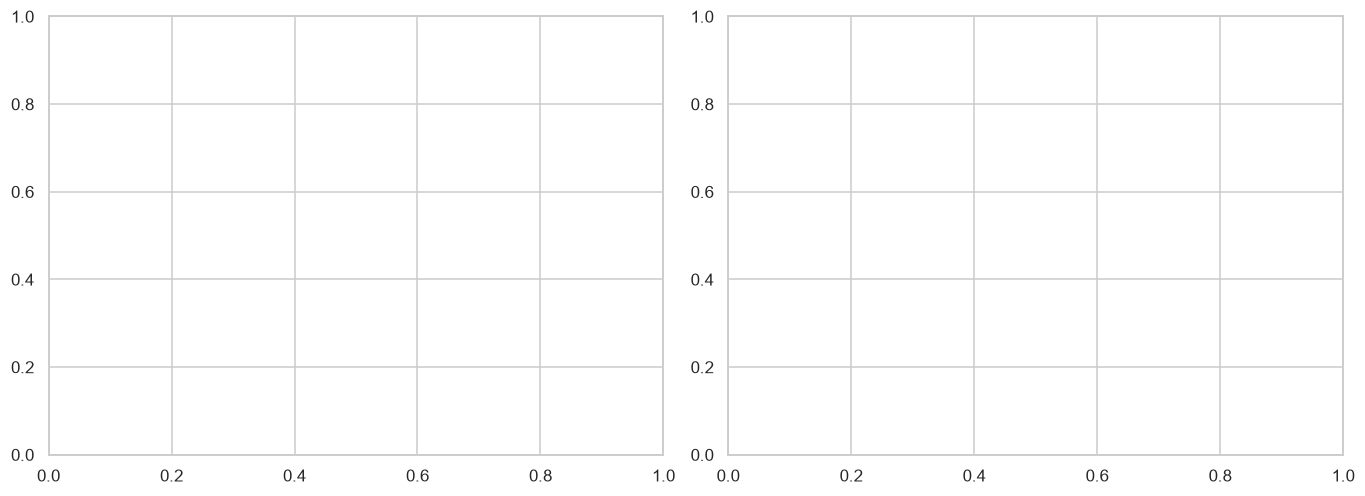

Block 7 charts: scaffold rendered.


In [12]:
# STEP 7.7 — two-panel figure: (left) horizontal avg-latency bars colored by tier with p95 labels;
# (right) hourly spike bars + avg-latency line (twin axis). Scaffold runs — add your calls.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
# TODO: left — ax1.barh(bank_profile['bank_name'], bank_profile['avg_latency_ms'], color=<tier colors>)
# TODO: right — ax2.bar(hourly['hour'], hourly['spikes']); twin axis for hourly['avg_latency_ms']
plt.tight_layout(); plt.show()
print("Block 7 charts: scaffold rendered.")

## 8 · Part 1 — KBQ 2: Error-Code Pareto — Infrastructure vs User-Side
**Goal (block 8):** Pareto of error codes over failed attempts (share % + cumulative %), the
infrastructure/user-side split, and the `USER_DROPPED ⇔ ERR_AUTH_FAILED` pairing check.
**Accounting rule:** `status='TIMEOUT'` rows and `error_code='ERR_BANK_TIMEOUT'` rows are different
populations — never sum them.
**Hints:** filter failures first · `value_counts()` gives the Pareto · `np.where(isin(...), ...)` tags
domains · `.cumsum()` builds the cumulative share · `groupby(['status', 'error_code']).size()` exposes
the pairing.

In [13]:
# STEP 8.1 — failures frame (worked)
df_failures = df_txns[df_txns["status"] != "SUCCESS"].copy()

# STEP 8.2 — Pareto: error_code counts sorted descending with share % and cumulative %
# hint: df_failures['error_code'].value_counts().rename_axis('error_code').reset_index(name='failures')
# hint: share = failures / failures.sum() * 100; cumulative = share.cumsum()
pareto = None  # TODO

# STEP 8.3 — fault domain: Infrastructure for {BANK_TIMEOUT, SWITCH_UNAVAILABLE, NPCI_DEGRADED}, else User-side
# hint: np.where(pareto['error_code'].isin(['ERR_BANK_TIMEOUT', 'ERR_SWITCH_UNAVAILABLE', 'ERR_NPCI_DEGRADED']),
#                'Infrastructure', 'User-side')  — then attach with pareto['fault_domain'] = ...
fault_domain = None  # TODO

# STEP 8.4 — pairing: (status, error_code) counts on failures — confirm USER_DROPPED 1:1 ERR_AUTH_FAILED
pairing = None  # TODO: df_failures.groupby(['status', 'error_code']).size().reset_index(name='n')

print("Block 8 status — pareto:", type(pareto).__name__, "| total failures:", len(df_failures))

Block 8 status — pareto: NoneType | total failures: 86437


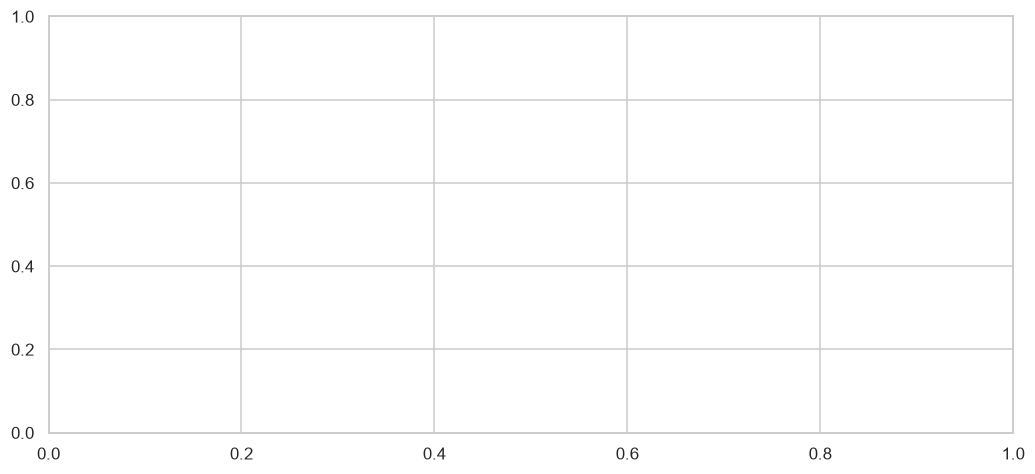

Block 8 charts: scaffold rendered.


In [14]:
# STEP 8.5 — Pareto chart: failure bars (colored by fault domain) + cumulative % line on a twin axis
fig, ax = plt.subplots(figsize=(9.5, 4.4))
# TODO: ax.bar(...) over pareto['failures'] / 1e3; twin axb = ax.twinx(); axb.plot(pareto['cumulative_pct'])
# TODO: xticklabels = pareto['error_code'] (rotation=20); legend for Infrastructure/User-side
plt.tight_layout(); plt.show()
print("Block 8 charts: scaffold rendered.")

## 9 · Part 2 — KBQ 3: Settlement Delay Diagnostics by Contracted SLA Cycle
**Goal (block 9):** breach rate + delay severity per contracted cycle, delay-day distribution,
monthly breach trend (≤ 2024-12), and the **MCC × cycle matrix** as a seaborn heatmap
(multivariate diagnostic #1).
**Hints:** join `df_merchants[['merchant_id', 'settlement_cycle_sla', 'mcc_category']]` onto
settlements · `mean()` of the 0/1 flag = breach rate · filter `batch_month <= '2024-12'` for the trend ·
`pivot_table(index=..., columns=..., values='sla_breach_flag', aggfunc='mean') * 100` builds the matrix ·
`sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd')` renders it.

In [15]:
# STEP 9.1 — settlements enriched with the merchant contract (worked)
df_settlements_merchants = df_settlements.merge(
    df_merchants[["merchant_id", "merchant_tier", "settlement_cycle_sla", "mcc_category"]],
    on="merchant_id")

# STEP 9.2 — per-cycle frame: batches, breach_pct, avg_delay_days (multiply breach by 100 after mean)
cycle = None  # TODO: groupby('settlement_cycle_sla').agg(...)

# STEP 9.3 — delay-day distribution: counts per settlement_delay_days value, sorted by day
delay_dist = None  # TODO: value_counts().sort_index()

# STEP 9.4 — monthly breach trend for batch_month <= '2024-12' (batches + breach %)
monthly_breach = None  # TODO

# STEP 9.5 — MCC x cycle breach matrix via pivot_table (values='sla_breach_flag', aggfunc='mean') * 100
mcc_matrix = None  # TODO: reindex(columns=['T_PLUS_0', 'T_PLUS_1', 'T_PLUS_2', 'T_PLUS_3'])

print("Block 9 status — cycle:", type(cycle).__name__, "| mcc_matrix:", type(mcc_matrix).__name__)

Block 9 status — cycle: NoneType | mcc_matrix: NoneType


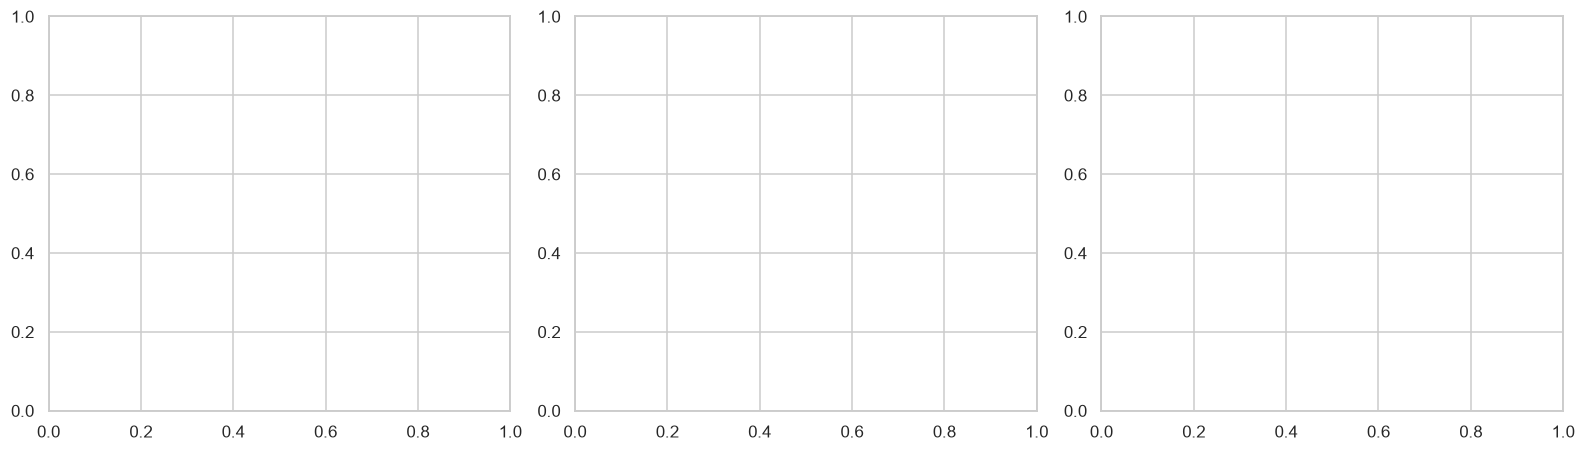

Block 9 charts: scaffold rendered.


In [16]:
# STEP 9.6 — three-panel figure: breach % by cycle · delay distribution · sns.heatmap of mcc_matrix
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
# TODO: axes[0] bars of cycle['breach_pct']; axes[1] bars of delay_dist; axes[2] sns.heatmap(mcc_matrix, annot=True)
plt.tight_layout(); plt.show()
print("Block 9 charts: scaffold rendered.")

## 10 · Part 2 — KBQ 4: Settlement Friction vs Merchant Attrition *(multivariate diagnostic #2)*
**Goal (block 10):** churn by tier; **churn by breach-bucket × tier** from `df_merchant_exposure`;
churn-reason decomposition; churned-merchant tenure.
**Hints:** `mean()` of the boolean `is_churned` = churn rate (× 100) · pivot the exposure groupby to
tier × bucket · reasons: filter churned merchants then `groupby(['merchant_tier', 'churn_reason']).size()`
· tenure: `(churn_date - onboarding_date).dt.days` averaged per tier.

In [17]:
# STEP 10.1 — churn by tier: merchants, churned, churn % (reindex to TIER_ORDER)
churn_tier = None  # TODO: df_merchants.groupby('merchant_tier').agg(... is_churned ...)

# STEP 10.2 — churn matrix: groupby(['merchant_tier', 'breach_bucket']) on df_merchant_exposure,
# then pivot to tier x bucket (values='churn_pct'); also keep the merchant counts pivot
churn_pivot = None  # TODO

# STEP 10.3 — SMB ratio: churn in the '>25%' bucket divided by churn in the '0-10%' bucket
smb_ratio = None  # TODO: churn_pivot.loc['SMB', '>25%'] / churn_pivot.loc['SMB', '0-10%']

# STEP 10.4 — churn reasons: (merchant_tier, churn_reason) counts for churned merchants only
reasons = None  # TODO

# STEP 10.5 — tenure: mean (churn_date - onboarding_date).dt.days per tier, churned merchants
tenure = None  # TODO

print("Block 10 status — churn_tier:", type(churn_tier).__name__, "| smb_ratio:", smb_ratio)

Block 10 status — churn_tier: NoneType | smb_ratio: None


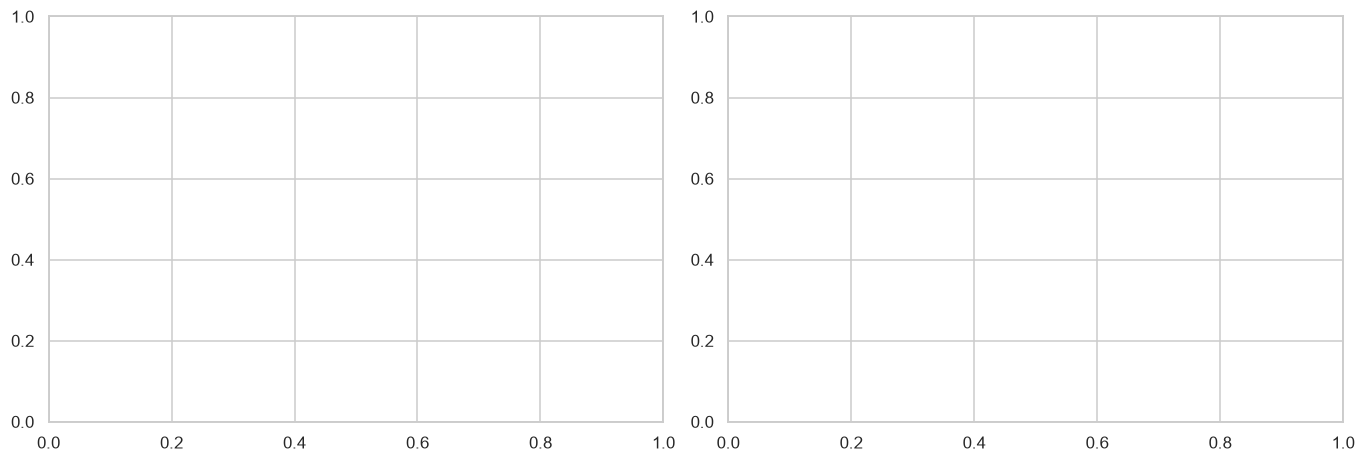

Block 10 charts: scaffold rendered.


In [18]:
# STEP 10.6 — two-panel figure: churn by breach bucket x tier (grouped bars, TIER_COLORS) ·
# SMB churn-reason bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
# TODO: loop tiers -> ax1.bar(x + offset, churn_pivot.loc[tier]); ax2.bar(reasons_smb['churn_reason'], ...)
plt.tight_layout(); plt.show()
print("Block 10 charts: scaffold rendered.")

## 11 · Part 3 — KBQ 5 & 6: Dynamic SLA Smart-Routing — A/B Lift & Latency Mitigation
**Goal (block 11):** A/B success rates (`is_routed_via_dynamic_sla` 0 vs 1), verify the benchmark
**+8.50 pp (band 8.30–8.70)** with an assertion, lift stability by tier and channel, latency
reduction (avg, p50, p95), and route × bank (multivariate diagnostics #3 and #4).
**Hints:** group the transaction frame by the routing flag with `success_rate` · `.unstack()` turns a
(tier × routed) groupby into the comparison table · `groupby(flag)['latency_ms'].quantile([0.50, 0.95])`
· overlay the latency distributions with `sns.histplot(data=..., x='latency_ms', hue='route',
bins=60, stat='density', element='step', fill=False)`.

In [19]:
# STEP 11.1 — A/B frame: txns, sr_pct, avg latency per routing flag
ab = None  # TODO: df_txns.groupby('is_routed_via_dynamic_sla').agg(...)

# STEP 11.2 — lift in percentage points: sr(routed=1) - sr(routed=0)
lift = None  # TODO

# STEP 11.3 — benchmark assertion (uncomment once 11.1-11.2 work)
# assert 8.30 <= lift <= 8.70, "Routing lift outside accepted band 8.30-8.70 pp!"

# STEP 11.4 — lift by tier: join tier onto transactions, groupby([tier, routed]) -> unstack
# hint: .unstack() pivots the routed level into columns 0/1; lift = column 1 - column 0
lift_tier = None  # TODO

# STEP 11.5 — lift by channel: same pattern joined on payment_method_id -> payment_channel
lift_channel = None  # TODO

print("Block 11 status — ab:", type(ab).__name__, "| lift:", lift)

Block 11 status — ab: NoneType | lift: None


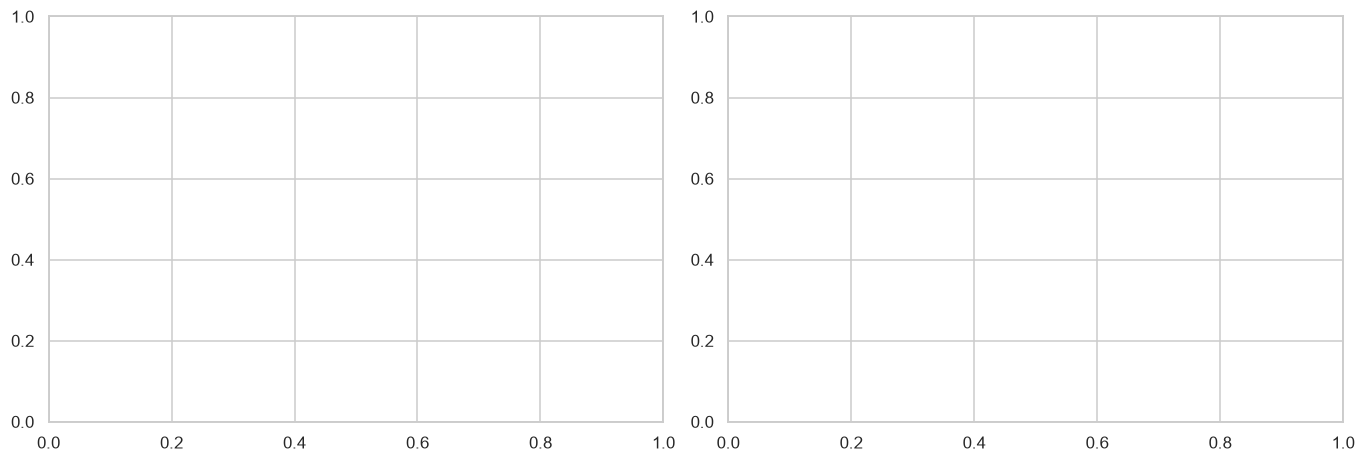

Block 11 charts: scaffold rendered.


In [20]:
# STEP 11.6 — latency by route: avg from ab + p50/p95 via groupby(flag)['latency_ms'].quantile([.5, .95]).unstack()
latency_route = None  # TODO

# STEP 11.7 — route x bank: mean latency pivot (bank rows x routed columns) + improvement_ms = column 0 - 1
route_bank = None  # TODO

# STEP 11.8 — figure: sns.histplot overlay of latency by route + worst-6-bank standard vs dynamic bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
# hint: build a labelled sample frame: df_route_latency = df_txns[['latency_ms', 'is_routed_via_dynamic_sla']].copy()
#       .assign(route=lambda d: d['is_routed_via_dynamic_sla'].map({0: 'Standard route', 1: 'Dynamic SLA route'}))
plt.tight_layout(); plt.show()
print("Block 11 charts: scaffold rendered.")

## 12 · Part 4 — KBQ 7: MDR Revenue Economics by Tier × Channel
**Goal (block 12):** realized MDR by tier (settlements), potential MDR by channel (success volume ×
contracted rate), tier × channel matrix, monthly realized trend (≤ 2024-12).
**Accounting:** realized (`net_mdr_deducted_inr`) ≠ potential (`amount_inr × mdr_rate_pct / 100`) —
never mix them; UPI's rate is 0%.
**Hints:** `df_success` from Block 6 already carries `mdr_amount_inr` · pivot_table for tier × channel ·
`df_settlements['settle_month']` powers the monthly trend.

In [21]:
# STEP 12.1 — realized by tier: settlements joined to merchant tiers; batches, GPV, MDR (Rs M)
realized_tier = None  # TODO: merge + groupby('merchant_tier').agg(...)

# STEP 12.2 — potential by channel: from df_success — gmv and mdr sums (Rs M) per payment_channel
potential_channel = None  # TODO

# STEP 12.3 — tier x channel potential matrix: pivot_table(values='mdr_amount_inr', aggfunc='sum') / 1e6
# hint: join merchant_tier onto df_success first (df_success.merge(df_merchants[['merchant_id', 'merchant_tier']]))
tier_channel = None  # TODO

# STEP 12.4 — monthly realized MDR: settle_month <= '2024-12', sum of net_mdr_deducted_inr (Rs M)
monthly_mdr = None  # TODO

print("Block 12 status — realized_tier:", type(realized_tier).__name__, "| potential_channel:", type(potential_channel).__name__)

Block 12 status — realized_tier: NoneType | potential_channel: NoneType


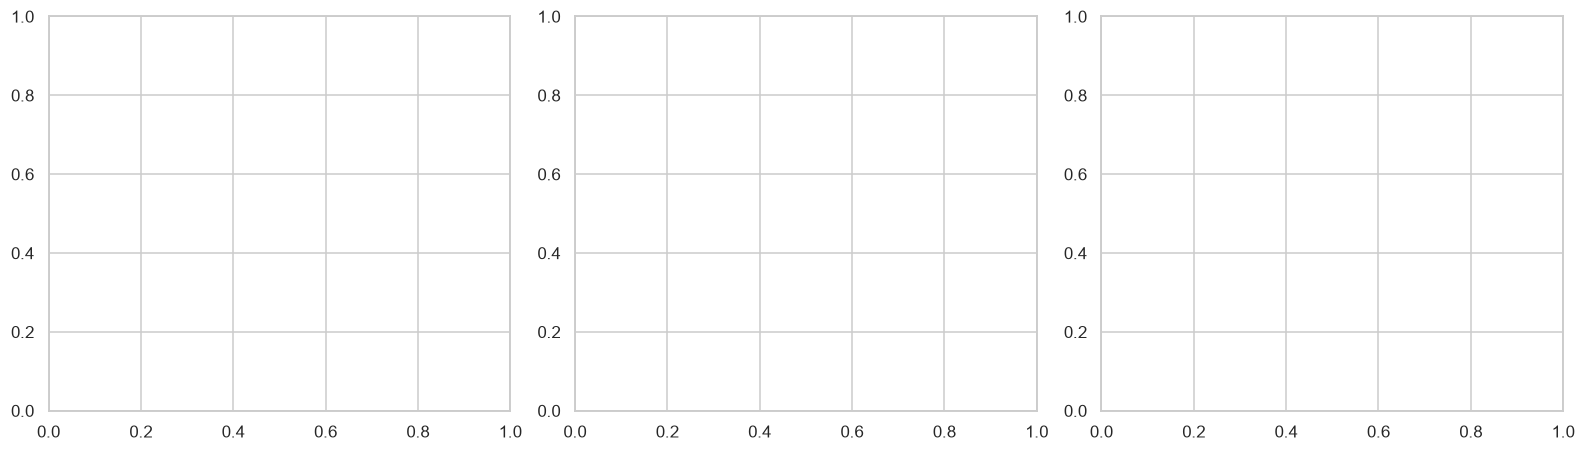

Block 12 charts: scaffold rendered.


In [22]:
# STEP 12.5 — three-panel figure: tier GPV + MDR (twin axes) · potential MDR by channel (barh + labels) ·
# monthly realized MDR line
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
# TODO: fill the three axes (axes[0], axes[1], axes[2]) with the visuals described above
plt.tight_layout(); plt.show()
print("Block 12 charts: scaffold rendered.")

## 13 · Part 4 — KBQ 8: Protected Volume — What Eliminating Settlement Delays Saves
**Goal (block 13):** size the at-risk SMB segment (> 25% breach bucket) and the annualized GMV/MDR
protected by fixing breaches. Two scenarios: **at-stake ceiling** (segment run-rate × 12/18) and
**excess-churn** (protected share = excess pp over the low-breach SMB baseline).
**Hints:** filter `df_merchant_exposure` on tier + bucket · churn % = `is_churned.mean() * 100` ·
annualize sums with `× 12 / 18` (justified by the flat monthly trends you produced in blocks 9/12) ·
`saveable = n_risk * excess_pp / 100`; protected volume = segment annualized × `excess_pp / 100` ·
state all four assumptions in a `print`.

In [23]:
# STEP 13.1 — at-risk segment: SMB merchants whose breach_bucket is '>25%'
# hint: at_risk = df_merchant_exposure[(df_merchant_exposure['merchant_tier'] == 'SMB')
#        & (df_merchant_exposure['breach_bucket'] == '>25%')]
at_risk = None  # TODO

# STEP 13.2 — segment metrics: n_risk, churn %, annualized GPV and MDR (Rs M / yr = 18-mo sum x 12/18)
n_risk, risk_churn_pct = None, None  # TODO
risk_gpv_annual_m, risk_mdr_annual_m = None, None  # TODO

# STEP 13.3 — baseline: churn % of SMB merchants in the '0-10%' bucket
baseline_churn_pct = None  # TODO

# STEP 13.4 — excess-churn scenario: excess_pp -> saveable merchants -> protected GPV/MDR (same excess share)
# hint: protected_share = excess_pp / 100
excess_pp, saveable = None, None  # TODO
protected_gpv_annual_m, protected_mdr_annual_m = None, None  # TODO

# STEP 13.5 — scenario table (metric/value rows) + two-scenario bar chart (GMV left, MDR right)
# TODO: display(pd.DataFrame({'metric': [...], 'value': [...]})); twin-axis bar chart
# TODO: print the four assumptions (run-rate annualization, churn reversion, average economics, no replacement credit)
print("Block 13 status — n_risk:", n_risk, "| excess_pp:", excess_pp)

Block 13 status — n_risk: None | excess_pp: None


## 14 · Findings → 5 Prioritized Recommendations & Executive Summary
**Goal (block 14):** convert evidence into **5 prioritized recommendations** — each
**Finding → Business Problem → Recommendation → Expected Impact**, impacts quantified from *your
computed variables* (never hardcoded), assumptions inline, top-3 starred ★ — then an executive-summary
table.
**Hints:** build one big `Markdown(f"""...""")` with f-string interpolations of your variables ·
`from IPython.display import Markdown` · keep the rec chain explicit; every impact needs an assumption.

In [24]:
# STEP 14.1 — import the renderer and assemble the narrative (scaffold below runs; extend it)
from IPython.display import Markdown, display as ipy_display

exec_md = Markdown("TODO: 5 recommendations (Finding -> Problem -> Recommendation -> Expected impact) "
                   "+ executive summary table, every number interpolated from your computed variables.")

# STEP 14.2 — display it
ipy_display(exec_md)

TODO: 5 recommendations (Finding -> Problem -> Recommendation -> Expected impact) + executive summary table, every number interpolated from your computed variables.